In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Exam_Score_Prediction.csv')

In [3]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(20000, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [8]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [9]:
df = df.drop('student_id', axis=1)

## Exploratory Data Analysis (EDA)

Let's start by analyzing the distribution of our target variable, `exam_score`.

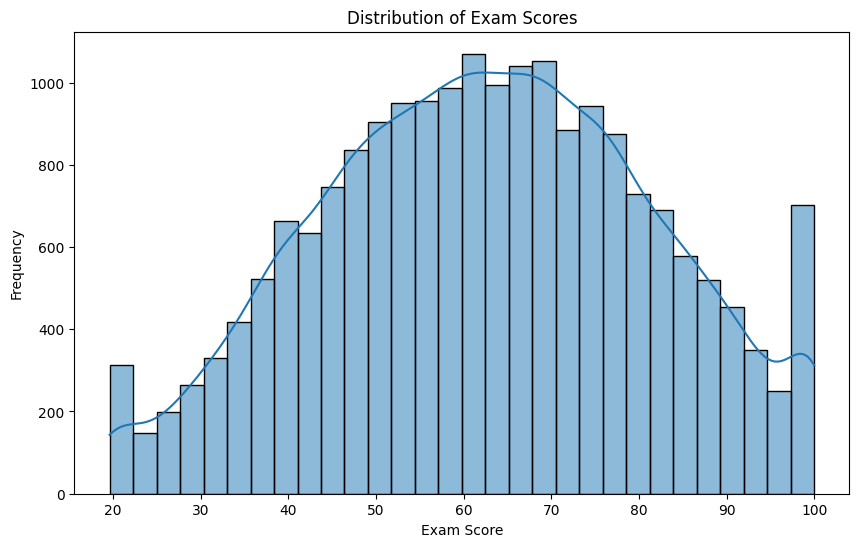

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['exam_score'], kde=True, bins=30)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

### Analyzing Numerical Features vs. Exam Score

Let's look at the relationship between numerical features and the exam score using scatter plots and correlation.

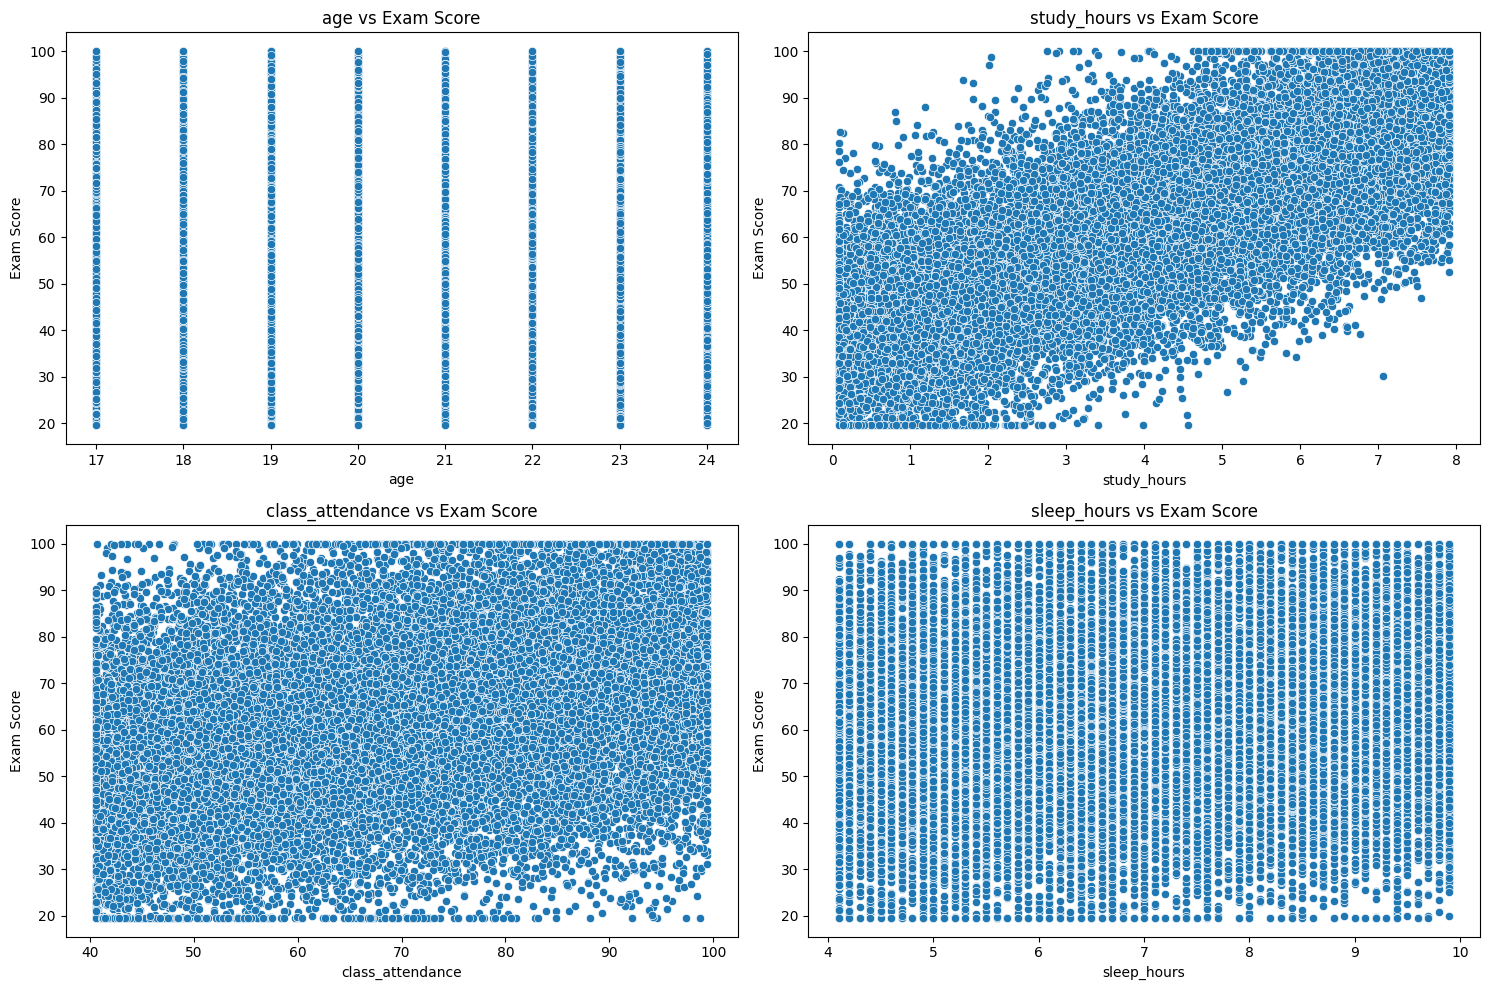

In [11]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['exam_score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

In [12]:
print('Correlation Matrix for Numerical Features and Exam Score:')
display(df[numerical_cols + ['exam_score']].corr()['exam_score'].sort_values(ascending=False))

Correlation Matrix for Numerical Features and Exam Score:


,exam_score
exam_score,1.000000
study_hours,0.717788
class_attendance,0.308850
sleep_hours,0.133222
age,0.006522


<Axes: >

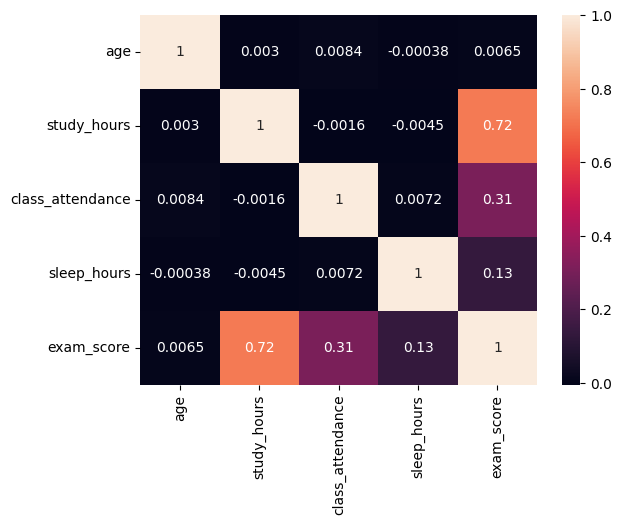

In [13]:
sns.heatmap(df[numerical_cols + ['exam_score']].corr(), annot=True)

### Analyzing Categorical Features vs. Exam Score

Now, let's explore how categorical features relate to the `exam_score` using box plots.

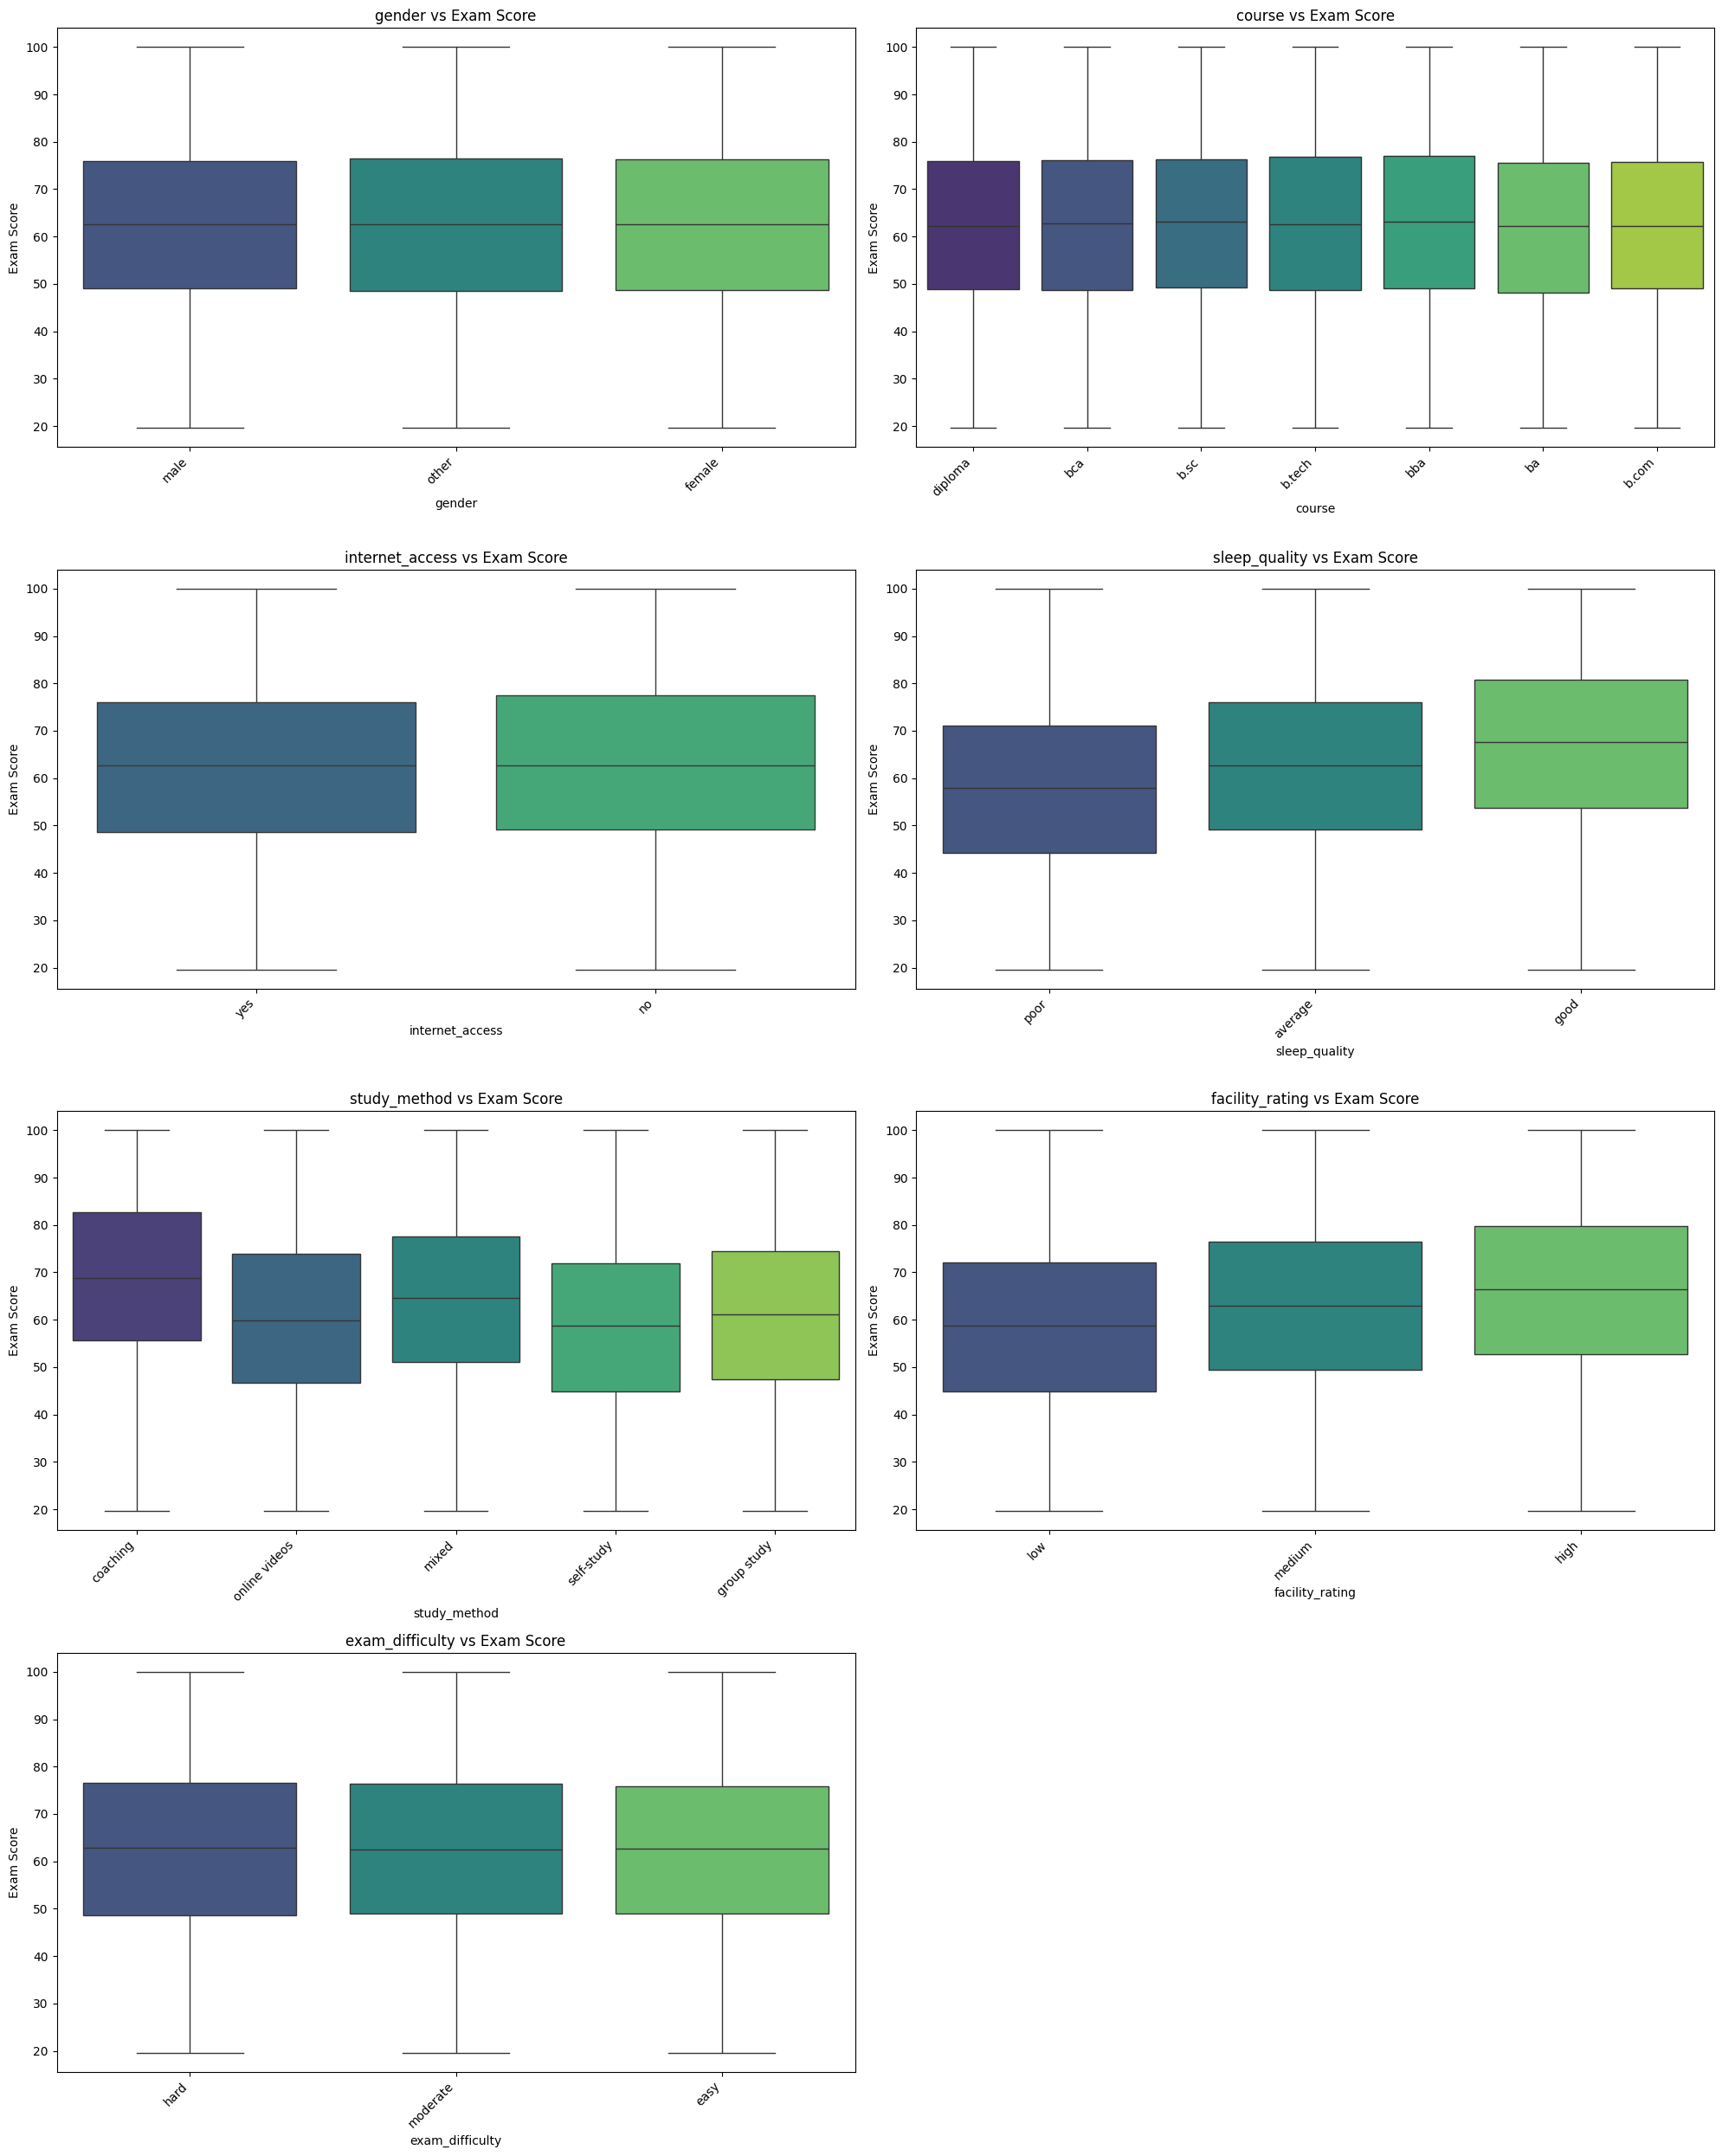

In [14]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(x=df[col], y=df['exam_score'], palette='viridis')
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## EDA Summary and Insights

The Exploratory Data Analysis process is complete, and here's a summary of our findings:

1.  **Exam Score Distribution**: The `exam_score` distribution appears to be roughly normal, centered around 60-70, with a decent spread, indicating a variety of performance levels among students.

2.  **Numerical Features vs. Exam Score**:
    *   `study_hours` shows a strong positive correlation (0.717788) with `exam_score`, suggesting that more study hours generally lead to higher scores. This is the strongest correlation among numerical features.
    *   `class_attendance` has a moderate positive correlation (0.308850), indicating that better attendance is associated with higher scores.
    *   `sleep_hours` has a weak positive correlation (0.133222), implying a slight positive relationship with exam scores, but not as strong as study hours or attendance.
    *   `age` has a negligible correlation (0.006522) with `exam_score`, meaning age doesn't significantly impact exam performance in this dataset.

3.  **Categorical Features vs. Exam Score**:
    *   **Gender**: There might be slight differences in median scores across genders, but a clear dominant trend is not immediately apparent without further statistical tests.
    *   **Course**: Different courses appear to have varying median exam scores, suggesting that the chosen course might influence performance.
    *   **Internet Access**: Students with internet access seem to have slightly higher scores on average than those without.
    *   **Sleep Quality**: Better sleep quality (good vs. average vs. poor) generally correlates with higher exam scores.
    *   **Study Method**: Certain study methods (e.g., 'coaching', 'group study') might be associated with higher scores compared to others (e.g., 'online videos', 'self-study').
    *   **Facility Rating**: Higher facility ratings ('high' vs. 'medium' vs. 'low') tend to correspond to better exam scores.
    *   **Exam Difficulty**: As expected, exams rated 'easy' or 'moderate' generally show higher average scores than 'hard' exams.

These insights will be valuable for feature engineering and model building for predicting exam scores.

### Statistical Tests for Categorical Features vs. Exam Score

To formally assess if there are significant differences in `exam_score` across the categories of each feature, we'll perform ANOVA (Analysis of Variance) tests. We will include `age` in this analysis, treating it as a categorical variable due to its limited range.

In [15]:
from scipy.stats import f_oneway

# Adding 'age' to the list of categorical columns for statistical testing
categorical_and_age_cols = categorical_cols + ['age']

print('ANOVA Test Results for Categorical Features vs. Exam Score:')
print('-' * 70)

for col in categorical_and_age_cols:
    # Get unique categories for the current column
    categories = df[col].unique()

    # Collect exam scores for each category
    data_to_compare = [df['exam_score'][df[col] == category] for category in categories]

    # Perform ANOVA test
    f_statistic, p_value = f_oneway(*data_to_compare)

    print(f'Feature: {col}')
    print(f'  F-statistic: {f_statistic:.2f}')
    print(f'  P-value: {p_value:.3f}')
    if p_value < 0.05:
        print(f'  Conclusion: There is a statistically significant difference in exam scores across {col} categories.')
    else:
        print(f'  Conclusion: No statistically significant difference in exam scores across {col} categories.')
    print('-' * 70)

ANOVA Test Results for Categorical Features vs. Exam Score:
----------------------------------------------------------------------
Feature: gender
  F-statistic: 0.19
  P-value: 0.826
  Conclusion: No statistically significant difference in exam scores across gender categories.
----------------------------------------------------------------------
Feature: course
  F-statistic: 0.61
  P-value: 0.719
  Conclusion: No statistically significant difference in exam scores across course categories.
----------------------------------------------------------------------
Feature: internet_access
  F-statistic: 1.22
  P-value: 0.268
  Conclusion: No statistically significant difference in exam scores across internet_access categories.
----------------------------------------------------------------------
Feature: sleep_quality
  F-statistic: 411.79
  P-value: 0.000
  Conclusion: There is a statistically significant difference in exam scores across sleep_quality categories.
----------------------

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64 ❌

 1   gender            20000 non-null  object ❌

 2   course            20000 non-null  object ⏸

 3   study_hours       20000 non-null  float64✅

 4   class_attendance  20000 non-null  float64✅

 5   internet_access   20000 non-null  object❌

 6   sleep_hours       20000 non-null  float64✅

 7   sleep_quality     20000 non-null  object

 8   study_method      20000 non-null  object

 9   facility_rating   20000 non-null  object

 10  exam_difficulty   20000 non-null  object

 11  exam_score        20000 non-null  float64

### Label Encoding for Categorical Features

Now, let's convert our categorical features into numerical representations using Label Encoding, which is suitable for ordinal and nominal categories where the number of unique values is not excessively high.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns for encoding (excluding 'exam_score' which is the target)
categorical_features = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

# Create a copy to avoid SettingWithCopyWarning and to keep original data if needed
df_encoded = df.copy()

# Apply LabelEncoder to each categorical feature
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'Column {col} encoded. Mappings: {list(le.classes_)} -> {list(le.transform(le.classes_))}')

print('\nDataFrame after Label Encoding:')
display(df_encoded.head())

Column gender encoded. Mappings: ['female', 'male', 'other'] -> [np.int64(0), np.int64(1), np.int64(2)]
Column course encoded. Mappings: ['b.com', 'b.sc', 'b.tech', 'ba', 'bba', 'bca', 'diploma'] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Column internet_access encoded. Mappings: ['no', 'yes'] -> [np.int64(0), np.int64(1)]
Column sleep_quality encoded. Mappings: ['average', 'good', 'poor'] -> [np.int64(0), np.int64(1), np.int64(2)]
Column study_method encoded. Mappings: ['coaching', 'group study', 'mixed', 'online videos', 'self-study'] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Column facility_rating encoded. Mappings: ['high', 'low', 'medium'] -> [np.int64(0), np.int64(1), np.int64(2)]
Column exam_difficulty encoded. Mappings: ['easy', 'hard', 'moderate'] -> [np.int64(0), np.int64(1), np.int64(2)]

DataFrame after Label Encoding:


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


In [18]:
X = df_encoded.drop(['exam_score','age','gender','internet_access','exam_difficulty','course'], axis=1)
y = df_encoded['exam_score']

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42)

In [21]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16000, 6)
(16000,)
(4000, 6)
(4000,)


In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Decision Tree Regressor Model Performance:')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Decision Tree Regressor Model Performance:
Mean Absolute Error (MAE): 11.77
Mean Squared Error (MSE): 218.09
Root Mean Squared Error (RMSE): 14.77
R-squared (R2): 0.39


In [23]:
from sklearn.ensemble import AdaBoostRegressor

# Initialize the AdaBoost Regressor model with default parameters
adaboost_model = AdaBoostRegressor(random_state=42)

# Train the model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate the model's performance
mae_adaboost = mean_absolute_error(y_test, y_pred_adaboost)
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
rmse_adaboost = np.sqrt(mse_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print('AdaBoost Regressor Model Performance:')
print(f'Mean Absolute Error (MAE): {mae_adaboost:.2f}')
print(f'Mean Squared Error (MSE): {mse_adaboost:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_adaboost:.2f}')
print(f'R-squared (R2): {r2_adaboost:.2f}')

AdaBoost Regressor Model Performance:
Mean Absolute Error (MAE): 8.89
Mean Squared Error (MSE): 118.18
Root Mean Squared Error (RMSE): 10.87
R-squared (R2): 0.67


In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the Gradient Boosting Regressor model with default parameters
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate the model's performance
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print('Gradient Boosting Regressor Model Performance:')
print(f'Mean Absolute Error (MAE): {mae_gbr:.2f}')
print(f'Mean Squared Error (MSE): {mse_gbr:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_gbr:.2f}')
print(f'R-squared (R2): {r2_gbr:.2f}')

Gradient Boosting Regressor Model Performance:
Mean Absolute Error (MAE): 7.97
Mean Squared Error (MSE): 97.43
Root Mean Squared Error (RMSE): 9.87
R-squared (R2): 0.73


In [25]:
import xgboost as xgb

# Initialize the XGBoost Regressor model with default parameters
xgb_model = xgb.XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model's performance
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print('XGBoost Regressor Model Performance:')
print(f'Mean Absolute Error (MAE): {mae_xgb:.2f}')
print(f'Mean Squared Error (MSE): {mse_xgb:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_xgb:.2f}')
print(f'R-squared (R2): {r2_xgb:.2f}')

XGBoost Regressor Model Performance:
Mean Absolute Error (MAE): 8.27
Mean Squared Error (MSE): 107.43
Root Mean Squared Error (RMSE): 10.36
R-squared (R2): 0.70


In [26]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage
    'max_depth': [3, 5, 7], # Maximum depth of a tree
    'min_child_weight': [1, 3], # Minimum sum of instance weight needed in a child
    'subsample': [0.7,0.8, 0.9], # Subsample ratio of the training instance
    'colsample_bytree': [0.7,0.8, 0.9], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2], # Minimum loss reduction required to make a further partition
}

# Initialize the XGBoost Regressor model
xgb_base_model = xgb.XGBRegressor(random_state=42, eval_metric='rmse') # eval_metric added to avoid warning

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base_model,
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    scoring='r2', # Use R-squared as the scoring metric
    verbose=2, # Increased verbosity to see the progress
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print('Best parameters found by GridSearchCV:')
print(grid_search.best_params_)

# Get the best model from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Evaluate the best model's performance
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print('\nBest XGBoost Regressor Model Performance (after GridSearchCV):')
print(f'Mean Absolute Error (MAE): {mae_best_xgb:.2f}')
print(f'Mean Squared Error (MSE): {mse_best_xgb:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}')
print(f'R-squared (R2): {r2_best_xgb:.2f}')

Fitting 3 folds for each of 1458 candidates, totalling 4374 fits
Best parameters found by GridSearchCV:
{'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

Best XGBoost Regressor Model Performance (after GridSearchCV):
Mean Absolute Error (MAE): 7.92
Mean Squared Error (MSE): 96.94
Root Mean Squared Error (RMSE): 9.85
R-squared (R2): 0.73


In [27]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Define the categorical features that were used in the final X for model training
features_to_encode_and_save = ['sleep_quality', 'study_method', 'facility_rating']

# Create a dictionary to store the fitted LabelEncoders
label_encoders = {}

# Re-fit LabelEncoders and save them to .pkl files
for col in features_to_encode_and_save:
    le = LabelEncoder()
    le.fit(df[col]) # Fit on the original (unencoded) column
    label_encoders[col] = le
    filename = f'label_encoder_{col}.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(le, file)
    print(f'Saved LabelEncoder for {col} to {filename}')

# Save the best XGBoost model to a .pkl file
model_filename = 'best_xgb_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb_model, file)
print(f'Saved best XGBoost model to {model_filename}')

Saved LabelEncoder for sleep_quality to label_encoder_sleep_quality.pkl
Saved LabelEncoder for study_method to label_encoder_study_method.pkl
Saved LabelEncoder for facility_rating to label_encoder_facility_rating.pkl
Saved best XGBoost model to best_xgb_model.pkl


In [28]:
X_train.columns

Index(['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating'],
      dtype='object')